In [17]:
# Setup and imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import pickle
import importlib
import os
import datetime
import glob
import time

# Import orig_clases - vehicle classes we want to avoid
import consts
importlib.reload(consts)
orig_clases = consts.orig_clases

from aruco_pose import get_camera_angles_from_frame
from capture_utils_v2 import CaptureSystem

tt = lambda x: torch.tensor(cv2.cvtColor(x, cv2.COLOR_BGR2RGB)/255.).permute(2,0,1).float()

print(f"Original vehicle classes to avoid: {orig_clases.tolist()}")
%matplotlib inline

Original vehicle classes to avoid: [817, 705, 609, 586, 436, 627, 468, 621, 803, 407, 408, 751, 717, 866, 661, 864]


In [18]:
# Initialize capture system
system = CaptureSystem()
cap = system.cap
print("✓ Camera initialized")

IC4 already opened, using existing grabber and sink.
✓ Camera initialized


In [19]:
# Load calibration state
with open("capture_system_state.pkl", "rb") as f:
    system.orig_proj_corners, system.corners_img_proj, system.orig_img = pickle.load(f)
print("✓ Calibration state loaded")

✓ Calibration state loaded


In [20]:
# Load all classifiers for evaluation
print("Loading classifiers...")

# Ensemble v1 classifier (Inception, ResNet, VGG, ViT, DINOv2)
import classfier_ensemble as ensemble_v1
ensemble_v1_weights = ensemble_v1.weights
print("✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)")

# Ensemble v2 classifier (ConvNeXt, EfficientNet, MobileNet, Swin)
import classfier_ensemble_v2 as ensemble_v2
ensemble_v2_weights = ensemble_v2.weights
print("✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)")

# DINOv2 standalone classifier
import classfier_dino as dino
dino_weights = dino.weights
print("✓ DINOv2 standalone classifier loaded")

categories = ensemble_v1_weights.meta["categories"]
print(f"\n✓ All classifiers ready for evaluation")

Loading classifiers...
✓ Ensemble v1 loaded (Inception, ResNet, VGG, ViT, DINOv2)
✓ Ensemble v2 loaded (ConvNeXt, EfficientNet, MobileNet, Swin)
✓ DINOv2 standalone classifier loaded

✓ All classifiers ready for evaluation


## Configure Patch Folders

Set the paths to the folders containing patches.

In [21]:
# ============================================
# CONFIGURE THESE PATHS
# ============================================

# Folder containing CAPAA patches (PNG/JPG files)
capaa_folder = r"C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all"

# Folder containing Best Patch patterns (PNG/JPG files)
best_patch_folder = r"C:\git\PhysicalAdverserialProj\results\ensamble_classifier_2025-12-24_21_20_top_patches"

# Capture delay in seconds (time to wait after projecting before capturing)
CAPTURE_DELAY = 1.0

# Multi-pose capture settings
MULTI_POSE = True  # Set to True to capture from multiple camera poses
NUM_POSES = 4       # Number of poses to capture (only used if MULTI_POSE=True)
NUM_CAPTURES = 10   # Number of frames to capture per patch per pose

# File extensions to look for
EXTENSIONS = ['*.png', '*.jpg', '*.jpeg']

# Projector setup info (same as in complete_attack_v2.ipynb)
PRJ_SCREEN_SZ = (1920, 1080)  # Projector screen resolution
PRJ_OFFSET = (2560, 0)        # Offset to move window to projector screen
PRJ_WINDOW_NAME = "Projector"

print(f"CAPAA folder: {capaa_folder}")
print(f"Best Patch folder: {best_patch_folder}")
print(f"Capture delay: {CAPTURE_DELAY}s")
print(f"Multi-pose: {MULTI_POSE} ({NUM_POSES} poses)" if MULTI_POSE else f"Multi-pose: {MULTI_POSE} (single pose)")
print(f"Frames per capture: {NUM_CAPTURES}")
print(f"Projector: {PRJ_SCREEN_SZ[0]}x{PRJ_SCREEN_SZ[1]} at offset {PRJ_OFFSET}")

CAPAA folder: C:\git\CAPAA\src\python\data\setups\jeep8\prj\adv\CAPAA_PCNet_l1+ssim_500_24_2000\camdE_caml2\5\classifier_all
Best Patch folder: C:\git\PhysicalAdverserialProj\results\ensamble_classifier_2025-12-24_21_20_top_patches
Capture delay: 1.0s
Multi-pose: True (4 poses)
Frames per capture: 10
Projector: 1920x1080 at offset (2560, 0)


In [22]:
# Load patch files from folders
def get_patch_files(folder, extensions=EXTENSIONS):
    """Get all image files from a folder."""
    files = []
    for ext in extensions:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(files)

capaa_patches = get_patch_files(capaa_folder)
best_patch_patches = get_patch_files(best_patch_folder)

print(f"\nFound {len(capaa_patches)} CAPAA patches:")
for p in capaa_patches[:5]:
    print(f"  - {os.path.basename(p)}")
if len(capaa_patches) > 5:
    print(f"  ... and {len(capaa_patches) - 5} more")

print(f"\nFound {len(best_patch_patches)} Best Patch files:")
for p in best_patch_patches[:5]:
    print(f"  - {os.path.basename(p)}")
if len(best_patch_patches) > 5:
    print(f"  ... and {len(best_patch_patches) - 5} more")


Found 11 CAPAA patches:
  - img_0001.png
  - img_0002.png
  - img_0003.png
  - img_0004.png
  - img_0005.png
  ... and 6 more

Found 17 Best Patch files:
  - 11_0.45.png
  - 12_0.36.png
  - 14_0.45.png
  - 15_0.27.png
  - 17_0.54.png
  ... and 12 more


## Batch Capture Function

In [23]:
def init_projector_window(window_name, screen_sz, offset):
    """
    Initialize a fullscreen projector window using cv2 (similar to init_prj_window).
    
    Args:
        window_name: Name for the window
        screen_sz: (width, height) of projector screen
        offset: (x, y) offset to move window to projector
    """
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.moveWindow(window_name, offset[0], offset[1])
    cv2.setWindowProperty(window_name, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    # Create black image initially
    black_img = np.zeros((screen_sz[1], screen_sz[0], 3), dtype=np.uint8)
    cv2.imshow(window_name, black_img)
    cv2.waitKey(1)
    return window_name


def project_image_cv2(window_name, img, screen_sz):
    """
    Project an image to the cv2 projector window, scaled to fit.
    
    Args:
        window_name: Name of the projector window
        img: Image to project (BGR format)
        screen_sz: (width, height) of projector screen
    """
    # Resize image to fit projector screen while maintaining aspect ratio
    h, w = img.shape[:2]
    scale = min(screen_sz[0] / w, screen_sz[1] / h)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Create black background
    display_img = np.zeros((screen_sz[1], screen_sz[0], 3), dtype=np.uint8)
    
    # Resize and center the image
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    x_offset = (screen_sz[0] - new_w) // 2
    y_offset = (screen_sz[1] - new_h) // 2
    display_img[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    cv2.imshow(window_name, display_img)
    cv2.waitKey(1)


def capture_multiple_frames(cap, num_frames=10):
    """
    Capture multiple frames for stability analysis.
    
    Args:
        cap: OpenCV VideoCapture object
        num_frames: Number of frames to capture
    
    Returns:
        List of captured frames (uint8)
    """
    frames = []
    for _ in range(num_frames):
        ret, frame = cap.read()
        if ret:
            frames.append(frame.copy())
        time.sleep(0.05)  # Small delay between captures (~20 FPS)
    
    return frames


def batch_capture_patches(cap, system, patch_files, approach_name, delay=1.0, 
                          window_name="Batch Capture", use_cv2_projector=False,
                          prj_screen_sz=None, prj_offset=None, num_captures=10,
                          multi_pose=False, num_poses=1):
    """
    Capture frames for multiple patches. Press 's' to START capturing.
    Captures multiple frames per patch for robust classification.
    
    Args:
        cap: OpenCV VideoCapture object
        system: CaptureSystem for projection (used for Best Patch)
        patch_files: List of patch file paths
        approach_name: Name of the approach (for display)
        delay: Seconds to wait after projecting before capturing
        window_name: Name for the camera display window
        use_cv2_projector: If True, use cv2 fullscreen window (for CAPAA)
        prj_screen_sz: Projector screen size (width, height)
        prj_offset: Projector window offset (x, y)
        num_captures: Number of frames to capture per patch per pose (default: 10)
        multi_pose: If True, capture from multiple poses (default: False)
        num_poses: Number of poses to capture from when multi_pose=True (default: 1)
    
    Returns:
        List of captured data with frames (list), pose, and patch info
        When multi_pose=True, each entry includes 'pose_idx' field
    """
    captured_data = []
    prj_window = None
    
    # Determine actual number of poses
    actual_num_poses = num_poses if multi_pose else 1
    
    print(f"\n{'='*60}")
    print(f"BATCH CAPTURE: {approach_name}")
    print(f"{'='*60}")
    print(f"Found {len(patch_files)} patches to process")
    print(f"Delay per patch: {delay}s")
    print(f"Frames per patch per pose: {num_captures}")
    if multi_pose:
        print(f"Multi-pose mode: ENABLED ({num_poses} poses)")
        print(f"Total frames to capture: {len(patch_files) * num_captures * num_poses}")
    else:
        print(f"Multi-pose mode: DISABLED (single pose)")
        print(f"Total frames to capture: {len(patch_files) * num_captures}")
    print(f"Projection mode: {'CV2 Fullscreen' if use_cv2_projector else 'CaptureSystem'}")
    print(f"\nPress 's' to START capturing each pose")
    print(f"Press 'q' to QUIT/abort")
    print(f"{'='*60}\n")
    
    # Create camera preview window on main display (position at top-left of primary screen)
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.moveWindow(window_name, 50, 50)  # Position on main display
    cv2.resizeWindow(window_name, 1280, 720)
    
    # Show initial camera frame before creating projector window
    print("Initializing camera preview...")
    for _ in range(10):  # Read a few frames to warm up camera
        ret, frame = cap.read()
        if ret:
            cv2.imshow(window_name, frame)
            cv2.waitKey(30)
    
    # Initialize projector window if using cv2 mode
    if use_cv2_projector and prj_screen_sz and prj_offset:
        prj_window = init_projector_window(PRJ_WINDOW_NAME, prj_screen_sz, prj_offset)
        # Bring camera preview back to focus
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)
        cv2.waitKey(1)
        cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 0)
    
    # Loop through each pose
    for pose_idx in range(actual_num_poses):
        pose_label = f"Pose {pose_idx + 1}/{actual_num_poses}" if multi_pose else "Single Pose"
        
        # Wait for 's' key to start this pose
        print(f"\n--- {pose_label} ---")
        print("Waiting for 's' key to start... Adjust camera position if needed.")
        started = False
        while not started:
            ret, frame = cap.read()
            if not ret:
                continue
            
            display_frame = frame.copy()
            cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 110), (40, 40, 40), -1)
            
            if multi_pose:
                cv2.putText(display_frame, f"{approach_name} - {pose_label}", 
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
                cv2.putText(display_frame, f"Press 's' to START this pose", 
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
            else:
                cv2.putText(display_frame, f"{approach_name} - Press 's' to START", 
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
            
            cv2.putText(display_frame, f"Patches: {len(patch_files)} | Frames/patch: {num_captures}", 
                        (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 2)
            
            # ArUco pose
            pose_result = get_camera_angles_from_frame(frame)
            if pose_result['found']:
                pose_text = f"Angle: {pose_result['angle']:.1f} deg | Dist: {pose_result['distance_m']:.2f}m"
                cv2.putText(display_frame, pose_text, (10, 140), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            else:
                cv2.putText(display_frame, "ArUco NOT DETECTED", (10, 140), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            
            cv2.imshow(window_name, display_frame)
            key = cv2.waitKey(30) & 0xFF
            
            if key == ord('s'):
                started = True
                print(f"\n✓ Starting capture for {pose_label}...\n")
            elif key == ord('q'):
                print("\n✗ Capture cancelled")
                cv2.destroyWindow(window_name)
                if prj_window:
                    cv2.destroyWindow(prj_window)
                return captured_data
        
        # Process each patch for this pose
        for patch_idx, patch_path in enumerate(patch_files):
            patch_name = os.path.basename(patch_path)
            print(f"[{pose_label}] [{patch_idx+1}/{len(patch_files)}] Processing: {patch_name}")
            
            # Load patch image
            try:
                patch_img = cv2.imread(patch_path)
                if patch_img is None:
                    print(f"  ✗ Failed to load image, skipping")
                    continue
                
                # Project the patch
                if use_cv2_projector and prj_window:
                    # Use cv2 fullscreen window for CAPAA
                    project_image_cv2(prj_window, patch_img, prj_screen_sz)
                else:
                    # Use CaptureSystem for Best Patch
                    patch_img_rgb = cv2.cvtColor(patch_img, cv2.COLOR_BGR2RGB)
                    system.plot_on_screen(patch_img_rgb)
                    
            except Exception as e:
                print(f"  ✗ Error projecting: {e}")
                continue
            
            # Wait for stabilization with live preview
            start_time = time.time()
            while (time.time() - start_time) < delay:
                ret, frame = cap.read()
                if not ret:
                    continue
                
                # Create display frame
                display_frame = frame.copy()
                remaining = delay - (time.time() - start_time)
                
                # Status bar
                cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 130), (40, 40, 40), -1)
                if multi_pose:
                    cv2.putText(display_frame, f"{approach_name} - {pose_label}", 
                                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
                else:
                    cv2.putText(display_frame, f"{approach_name} - Patch {patch_idx+1}/{len(patch_files)}", 
                                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
                cv2.putText(display_frame, f"Patch {patch_idx+1}/{len(patch_files)}: {patch_name}", 
                            (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
                cv2.putText(display_frame, f"Capturing in: {remaining:.1f}s", 
                            (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                
                # ArUco pose
                pose_result = get_camera_angles_from_frame(frame)
                if pose_result['found']:
                    pose_text = f"Angle: {pose_result['angle']:.1f} deg | Dist: {pose_result['distance_m']:.2f}m"
                    cv2.putText(display_frame, pose_text, (10, 120), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                else:
                    cv2.putText(display_frame, "ArUco NOT DETECTED", (10, 120), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                
                cv2.imshow(window_name, display_frame)
                key = cv2.waitKey(30) & 0xFF
                if key == ord('q'):
                    print("\n✗ Capture aborted by user")
                    cv2.destroyWindow(window_name)
                    if prj_window:
                        cv2.destroyWindow(prj_window)
                    return captured_data
            
            # Show "Capturing..." status
            ret, preview_frame = cap.read()
            if ret:
                display_frame = preview_frame.copy()
                cv2.rectangle(display_frame, (0, 0), (display_frame.shape[1], 100), (40, 40, 40), -1)
                cv2.putText(display_frame, f"Capturing {num_captures} frames...", 
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
                cv2.imshow(window_name, display_frame)
                cv2.waitKey(1)
            
            # Capture multiple frames
            frames = capture_multiple_frames(cap, num_frames=num_captures)
            if len(frames) == 0:
                print(f"  ✗ Failed to capture frames")
                continue
            
            # Get pose from the first frame (should be consistent across all)
            pose_result = get_camera_angles_from_frame(frames[0])
            
            capture_entry = {
                'patch_idx': patch_idx,
                'patch_name': patch_name,
                'patch_path': patch_path,
                'frames': frames,  # List of all captured frames
                'num_frames': len(frames),
                'angle': pose_result['angle'] if pose_result['found'] else None,
                'distance': pose_result['distance_m'] if pose_result['found'] else None
            }
            
            # Add pose index if multi_pose mode
            if multi_pose:
                capture_entry['pose_idx'] = pose_idx
            
            captured_data.append(capture_entry)
            
            if pose_result['found']:
                print(f"  ✓ Captured {len(frames)} frames: Angle={pose_result['angle']:.1f}°, Dist={pose_result['distance_m']:.2f}m")
            else:
                print(f"  ⚠ Captured {len(frames)} frames (no ArUco detected)")
            
            # Brief flash to indicate capture complete
            flash_frame = frames[-1].copy() if frames else preview_frame.copy()
            cv2.rectangle(flash_frame, (0, 0), (flash_frame.shape[1], flash_frame.shape[0]), (0, 255, 0), 10)
            cv2.imshow(window_name, flash_frame)
            cv2.waitKey(100)
        
        # After completing all patches for this pose
        if multi_pose and pose_idx < actual_num_poses - 1:
            print(f"\n✓ {pose_label} complete!")
            print(f"   Adjust camera position for next pose...")
    
    cv2.destroyWindow(window_name)
    if prj_window:
        cv2.destroyWindow(prj_window)
    
    total_frames = sum(cap_data['num_frames'] for cap_data in captured_data)
    if multi_pose:
        print(f"\n✓ Batch capture complete: {len(patch_files)} patches × {actual_num_poses} poses = {len(captured_data)} captures, {total_frames} total frames")
    else:
        print(f"\n✓ Batch capture complete: {len(captured_data)} patches, {total_frames} total frames")
    return captured_data

## Run Batch Capture for CAPAA Patches

In [24]:
# Capture all CAPAA patches (using cv2 fullscreen projector window)
# Uses global MULTI_POSE and NUM_POSES settings
capaa_captures = batch_capture_patches(
    cap=cap,
    system=system,
    patch_files=capaa_patches,
    approach_name="CAPAA",
    delay=CAPTURE_DELAY,
    window_name="CAPAA Batch Capture",
    use_cv2_projector=True,
    prj_screen_sz=PRJ_SCREEN_SZ,
    prj_offset=PRJ_OFFSET,
    num_captures=NUM_CAPTURES,
    multi_pose=MULTI_POSE,
    num_poses=NUM_POSES
)


BATCH CAPTURE: CAPAA
Found 11 patches to process
Delay per patch: 1.0s
Frames per patch per pose: 10
Multi-pose mode: ENABLED (4 poses)
Total frames to capture: 440
Projection mode: CV2 Fullscreen

Press 's' to START capturing each pose
Press 'q' to QUIT/abort

Initializing camera preview...

--- Pose 1/4 ---
Waiting for 's' key to start... Adjust camera position if needed.

✓ Starting capture for Pose 1/4...

[Pose 1/4] [1/11] Processing: img_0001.png
  ✓ Captured 10 frames: Angle=15.2°, Dist=0.90m
[Pose 1/4] [2/11] Processing: img_0002.png
  ✓ Captured 10 frames: Angle=15.5°, Dist=0.90m
[Pose 1/4] [3/11] Processing: img_0003.png
  ✓ Captured 10 frames: Angle=16.2°, Dist=0.90m
[Pose 1/4] [4/11] Processing: img_0004.png
  ✓ Captured 10 frames: Angle=15.4°, Dist=0.90m
[Pose 1/4] [5/11] Processing: img_0005.png
  ✓ Captured 10 frames: Angle=15.8°, Dist=0.90m
[Pose 1/4] [6/11] Processing: img_0006.png
  ✓ Captured 10 frames: Angle=16.0°, Dist=0.90m
[Pose 1/4] [7/11] Processing: img_0007.

## Run Batch Capture for Best Patch Patterns

In [ ]:
# Capture all Best Patch patterns (using CaptureSystem projection)
# Uses global MULTI_POSE and NUM_POSES settings
best_patch_captures = batch_capture_patches(
    cap=cap,
    system=system,
    patch_files=best_patch_patches,
    approach_name="Best Patch",
    delay=CAPTURE_DELAY,
    window_name="Best Patch Batch Capture",
    use_cv2_projector=False,  # Use CaptureSystem.plot_on_screen
    num_captures=NUM_CAPTURES,
    multi_pose=MULTI_POSE,
    num_poses=NUM_POSES
)


BATCH CAPTURE: Best Patch
Found 17 patches to process
Delay per patch: 1.0s
Frames per patch per pose: 10
Multi-pose mode: ENABLED (4 poses)
Total frames to capture: 680
Projection mode: CaptureSystem

Press 's' to START capturing each pose
Press 'q' to QUIT/abort

Initializing camera preview...

--- Pose 1/4 ---
Waiting for 's' key to start... Adjust camera position if needed.


## Classify All Captured Frames

In [ ]:
def classify_captures(captures, approach_name):
    """
    Classify all captured frames with all models.
    Each patch has multiple frames - classify each one individually.
    Supports multi-pose mode (includes pose_idx if present).
    """
    results = []
    
    for cap_data in tqdm(captures, desc=f"Classifying {approach_name}"):
        frames = cap_data['frames']
        
        # Classify each frame individually
        for frame_idx, frame in enumerate(frames):
            result_row = {
                'approach': approach_name,
                'patch_idx': cap_data['patch_idx'],
                'patch_name': cap_data['patch_name'],
                'frame_idx': frame_idx,
                'angle': cap_data['angle'],
                'distance': cap_data['distance'],
            }
            
            # Add pose_idx if present (multi-pose mode)
            if 'pose_idx' in cap_data:
                result_row['pose_idx'] = cap_data['pose_idx']
            
            # Prepare tensor
            img_tensor = tt(frame).unsqueeze(0).cuda()
            
            with torch.no_grad():
                v1_preds = ensemble_v1.predict_raw_per_model(img_tensor)
                v2_preds = ensemble_v2.predict_raw_per_model(img_tensor)
                dino_preds = dino.predict_raw(img_tensor)
            
            # V1 models
            for model_name in ['inception', 'resnet', 'vgg', 'vit', 'dino']:
                if model_name in v1_preds:
                    probs = v1_preds[model_name]
                    pred_idx = probs[0].argmax().item()
                    is_success = pred_idx not in orig_clases.tolist()
                    result_row[f'v1_{model_name}_success'] = is_success
                    result_row[f'v1_{model_name}_class'] = categories[pred_idx]
            
            # V1 Combined
            if 'ensemble' in v1_preds:
                pred_idx = v1_preds['ensemble'][0].argmax().item()
                result_row['v1_combined_success'] = pred_idx not in orig_clases.tolist()
                result_row['v1_combined_class'] = categories[pred_idx]
            
            # V2 models
            for model_name in ['convnext', 'efficientnet', 'mobilenet', 'swin']:
                if model_name in v2_preds:
                    probs = v2_preds[model_name]
                    pred_idx = probs[0].argmax().item()
                    is_success = pred_idx not in orig_clases.tolist()
                    result_row[f'v2_{model_name}_success'] = is_success
                    result_row[f'v2_{model_name}_class'] = categories[pred_idx]
            
            # V2 Combined
            if 'ensemble' in v2_preds:
                pred_idx = v2_preds['ensemble'][0].argmax().item()
                result_row['v2_combined_success'] = pred_idx not in orig_clases.tolist()
                result_row['v2_combined_class'] = categories[pred_idx]
            
            # DINOv2 standalone
            pred_idx = dino_preds[0].argmax().item()
            result_row['dino_standalone_success'] = pred_idx not in orig_clases.tolist()
            result_row['dino_standalone_class'] = categories[pred_idx]
            
            results.append(result_row)
    
    return pd.DataFrame(results)

# Classify both approaches (all frames)
capaa_df = classify_captures(capaa_captures, "CAPAA")
bp_df = classify_captures(best_patch_captures, "Best Patch")

# Check if multi-pose mode was used
capaa_multi_pose = 'pose_idx' in capaa_df.columns if len(capaa_df) > 0 else False
bp_multi_pose = 'pose_idx' in bp_df.columns if len(bp_df) > 0 else False

if capaa_multi_pose:
    num_poses = capaa_df['pose_idx'].nunique()
    print(f"\n✓ CAPAA: {len(capaa_df)} frames classified ({len(capaa_captures)} captures = patches × {num_poses} poses × frames)")
else:
    print(f"\n✓ CAPAA: {len(capaa_df)} frames classified ({len(capaa_captures)} patches × frames)")

if bp_multi_pose:
    num_poses = bp_df['pose_idx'].nunique()
    print(f"✓ Best Patch: {len(bp_df)} frames classified ({len(best_patch_captures)} captures = patches × {num_poses} poses × frames)")
else:
    print(f"✓ Best Patch: {len(bp_df)} frames classified ({len(best_patch_captures)} patches × frames)")

Classifying Best Patch: 100%|██████████| 17/17 [00:15<00:00,  1.13it/s]


✓ CAPAA: 110 frames classified (11 patches × frames)
✓ Best Patch: 170 frames classified (17 patches × frames)


## Results Summary

In [ ]:
# Calculate success rates - both per-frame and per-patch (majority vote)
# Supports multi-pose mode with per-pose breakdown
def summarize_success_rates(df, approach_name):
    """Calculate success rates for each model - per frame and per patch.
    Supports multi-pose mode with breakdown by pose."""
    success_cols = [c for c in df.columns if c.endswith('_success')]
    is_multi_pose = 'pose_idx' in df.columns
    
    print(f"\n{'='*70}")
    print(f"{approach_name} SUCCESS RATES")
    print(f"{'='*70}")
    
    num_patches = df['patch_idx'].nunique()
    num_frames = len(df)
    
    if is_multi_pose:
        num_poses = df['pose_idx'].nunique()
        print(f"Multi-pose mode: {num_poses} poses")
        print(f"Total patches: {num_patches}")
        print(f"Total captures: {num_patches * num_poses} (patches × poses)")
        print(f"Total frames: {num_frames}")
    else:
        print(f"Total patches: {num_patches}")
        print(f"Total frames: {num_frames}")
    
    # Per-frame success rates
    print(f"\n--- PER-FRAME Success Rates (ALL) ---")
    print(f"{'Model':<25} {'Success Rate':>15} {'Successful':>15}")
    print("-"*60)
    
    summary = []
    for col in success_cols:
        model_name = col.replace('_success', '')
        success_rate = df[col].mean() * 100
        success_count = df[col].sum()
        print(f"{model_name:<25} {success_rate:>14.1f}% {success_count:>12}/{num_frames}")
        summary.append({
            'Model': model_name, 
            'Frame Success Rate': success_rate, 
            'Frame Successful': success_count,
            'Total Frames': num_frames
        })
    
    # Per-pose breakdown if multi-pose
    if is_multi_pose:
        print(f"\n--- PER-POSE Frame Success Rates ---")
        for pose_idx in sorted(df['pose_idx'].unique()):
            pose_df = df[df['pose_idx'] == pose_idx]
            print(f"\nPose {pose_idx + 1}:")
            print(f"{'Model':<25} {'Success Rate':>15}")
            print("-"*45)
            for col in success_cols:
                model_name = col.replace('_success', '')
                success_rate = pose_df[col].mean() * 100
                print(f"{model_name:<25} {success_rate:>14.1f}%")
    
    # Per-patch success rates (majority vote across frames)
    # For multi-pose, group by patch_idx only (across all poses)
    print(f"\n--- PER-PATCH Success Rates (majority vote across all frames/poses) ---")
    print(f"{'Model':<25} {'Success Rate':>15} {'Successful':>15}")
    print("-"*60)
    
    for i, col in enumerate(success_cols):
        model_name = col.replace('_success', '')
        # Majority vote: patch is successful if >50% of frames are successful
        patch_success = df.groupby('patch_idx')[col].mean() > 0.5
        patch_success_rate = patch_success.mean() * 100
        patch_success_count = patch_success.sum()
        print(f"{model_name:<25} {patch_success_rate:>14.1f}% {patch_success_count:>12}/{num_patches}")
        summary[i]['Patch Success Rate'] = patch_success_rate
        summary[i]['Patch Successful'] = patch_success_count
        summary[i]['Total Patches'] = num_patches
    
    return pd.DataFrame(summary)

capaa_summary = summarize_success_rates(capaa_df, "CAPAA")
bp_summary = summarize_success_rates(bp_df, "Best Patch")


CAPAA SUCCESS RATES
Total patches: 11
Total frames: 110 (10 per patch)

--- PER-FRAME Success Rates ---
Model                        Success Rate      Successful
------------------------------------------------------------
v1_inception                        17.3%           19/110
v1_resnet                           11.8%           13/110
v1_vgg                               0.0%            0/110
v1_vit                               5.5%            6/110
v1_dino                             58.2%           64/110
v1_combined                          9.1%           10/110
v2_convnext                         80.0%           88/110
v2_efficientnet                      0.0%            0/110
v2_mobilenet                         0.0%            0/110
v2_swin                              0.0%            0/110
v2_combined                          0.0%            0/110
dino_standalone                     58.2%           64/110

--- PER-PATCH Success Rates (majority vote) ---
Model              

In [ ]:
# Per-patch detailed results (aggregated across frames)
# Supports multi-pose mode - groups by patch and pose if available
def aggregate_patch_results(df):
    """Aggregate frame results to patch level with success counts.
    If multi-pose, groups by patch_idx and pose_idx."""
    success_cols = [c for c in df.columns if c.endswith('_success')]
    is_multi_pose = 'pose_idx' in df.columns
    
    agg_dict = {
        'angle': 'first',
        'distance': 'first',
        'frame_idx': 'count'  # Count frames
    }
    for col in success_cols:
        agg_dict[col] = ['sum', 'mean']  # Count successes and rate
    
    if is_multi_pose:
        group_cols = ['patch_idx', 'patch_name', 'pose_idx']
    else:
        group_cols = ['patch_idx', 'patch_name']
    
    patch_df = df.groupby(group_cols).agg(agg_dict).reset_index()
    patch_df.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col 
                        for col in patch_df.columns.values]
    return patch_df

capaa_patch_df = aggregate_patch_results(capaa_df)
bp_patch_df = aggregate_patch_results(bp_df)

print("\n" + "="*100)
print("CAPAA - PER PATCH RESULTS (success count / total frames)")
print("="*100)

# Build display columns based on what's available
base_cols = ['patch_name']
if 'pose_idx' in capaa_patch_df.columns:
    base_cols.append('pose_idx')
base_cols.extend(['angle_first', 'distance_first', 'frame_idx_count'])

metric_cols = ['v1_combined_success_sum', 'v1_combined_success_mean',
               'v2_combined_success_sum', 'v2_combined_success_mean',
               'dino_standalone_success_sum', 'dino_standalone_success_mean']

display_cols = base_cols + metric_cols
available_cols = [c for c in display_cols if c in capaa_patch_df.columns]
print(capaa_patch_df[available_cols].to_string())

print("\n" + "="*100)
print("BEST PATCH - PER PATCH RESULTS (success count / total frames)")
print("="*100)

base_cols = ['patch_name']
if 'pose_idx' in bp_patch_df.columns:
    base_cols.append('pose_idx')
base_cols.extend(['angle_first', 'distance_first', 'frame_idx_count'])

display_cols = base_cols + metric_cols
available_cols = [c for c in display_cols if c in bp_patch_df.columns]
print(bp_patch_df[available_cols].to_string())


CAPAA - PER PATCH RESULTS (success count / total frames)
      patch_name  angle_first  distance_first  frame_idx_count  v1_combined_success_sum  v1_combined_success_mean  v2_combined_success_sum  v2_combined_success_mean  dino_standalone_success_sum  dino_standalone_success_mean
0   img_0001.png    22.306438        0.877013               10                        0                       0.0                        0                       0.0                            0                           0.0
1   img_0002.png    20.969574        0.889365               10                        0                       0.0                        0                       0.0                            8                           0.8
2   img_0003.png          NaN             NaN               10                        0                       0.0                        0                       0.0                           10                           1.0
3   img_0004.png    16.085473        0.907734 

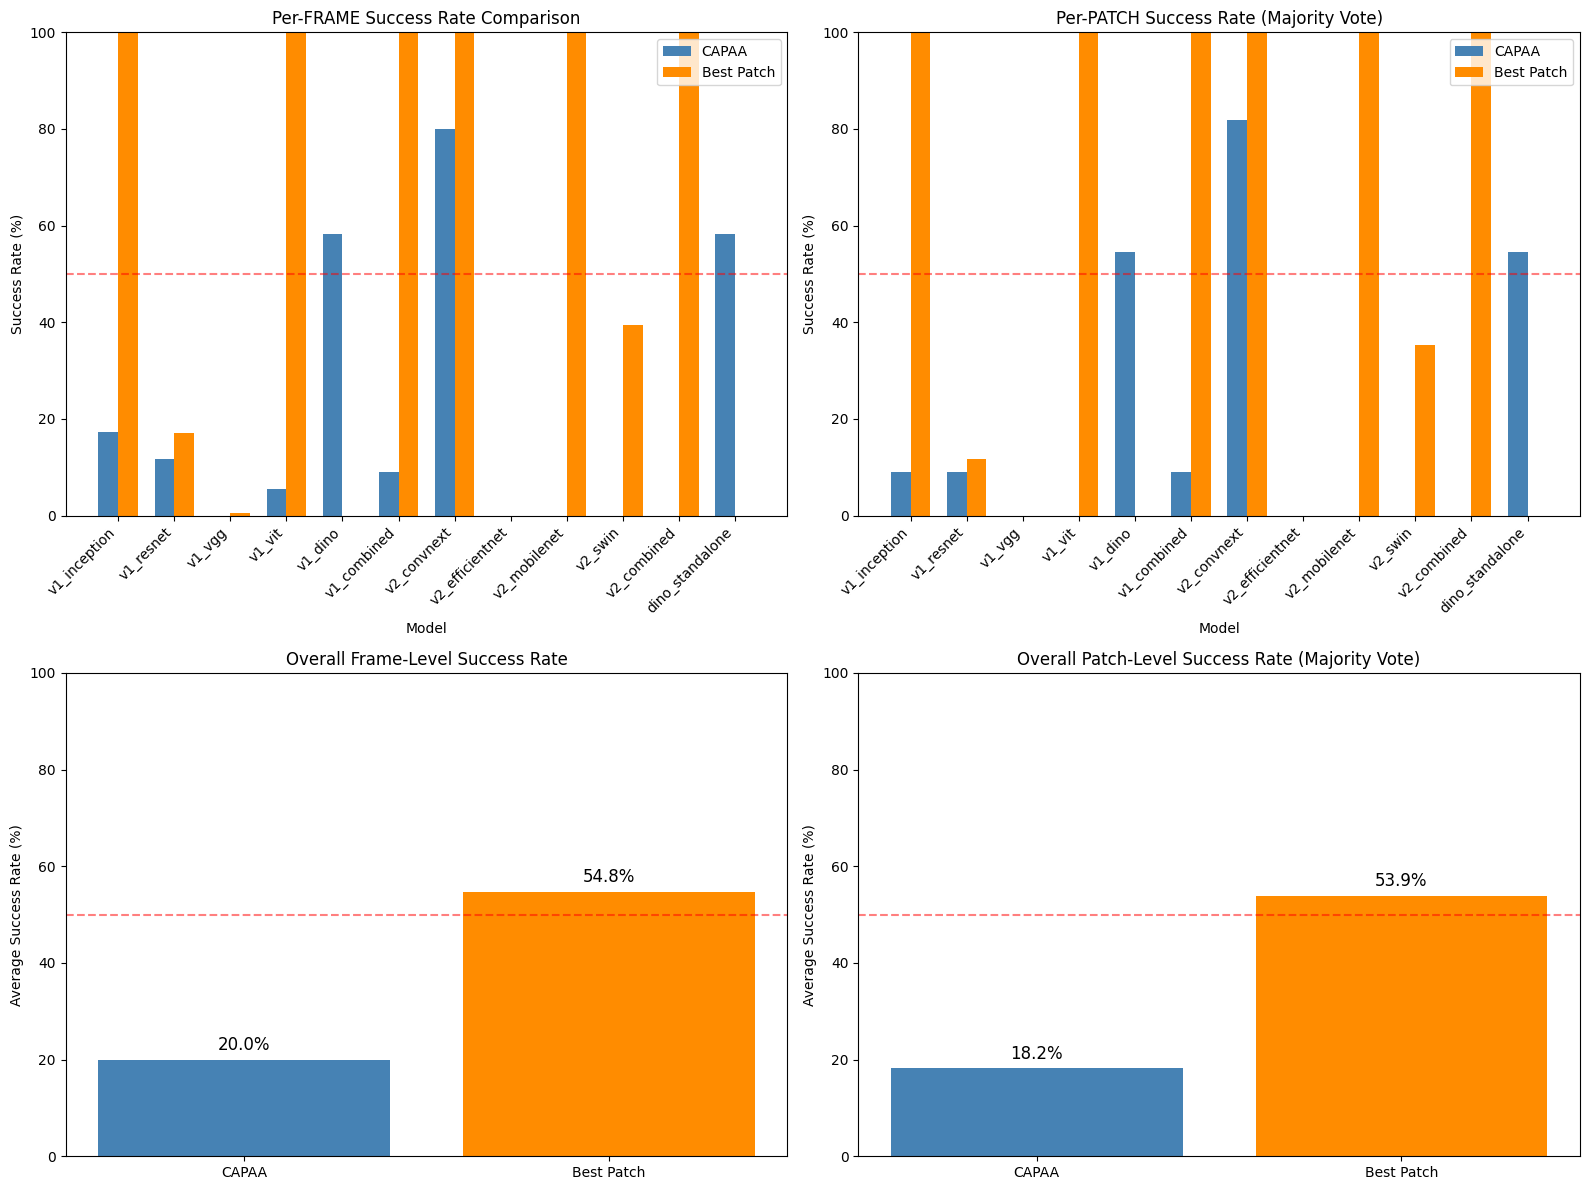

✓ Comparison saved to 'batch_capture_comparison.png'


In [ ]:
# Combined comparison chart - using both frame-level and patch-level metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Merge summaries for comparison
capaa_summary['Approach'] = 'CAPAA'
bp_summary['Approach'] = 'Best Patch'

# 1. Per-Frame Success Rate comparison
ax = axes[0, 0]
x = np.arange(len(capaa_summary))
width = 0.35
ax.bar(x - width/2, capaa_summary['Frame Success Rate'], width, label='CAPAA', color='steelblue')
ax.bar(x + width/2, bp_summary['Frame Success Rate'], width, label='Best Patch', color='darkorange')
ax.set_xlabel('Model')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Per-FRAME Success Rate Comparison')
ax.set_xticks(x)
ax.set_xticklabels(capaa_summary['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 2. Per-Patch Success Rate comparison (majority vote)
ax = axes[0, 1]
ax.bar(x - width/2, capaa_summary['Patch Success Rate'], width, label='CAPAA', color='steelblue')
ax.bar(x + width/2, bp_summary['Patch Success Rate'], width, label='Best Patch', color='darkorange')
ax.set_xlabel('Model')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Per-PATCH Success Rate (Majority Vote)')
ax.set_xticks(x)
ax.set_xticklabels(capaa_summary['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)

# 3. Average frame success rate per approach
ax = axes[1, 0]
avg_capaa_frame = capaa_summary['Frame Success Rate'].mean()
avg_bp_frame = bp_summary['Frame Success Rate'].mean()
bars = ax.bar(['CAPAA', 'Best Patch'], [avg_capaa_frame, avg_bp_frame], 
               color=['steelblue', 'darkorange'])
ax.set_ylabel('Average Success Rate (%)')
ax.set_title('Overall Frame-Level Success Rate')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
for bar, val in zip(bars, [avg_capaa_frame, avg_bp_frame]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{val:.1f}%', ha='center', fontsize=12)

# 4. Average patch success rate per approach
ax = axes[1, 1]
avg_capaa_patch = capaa_summary['Patch Success Rate'].mean()
avg_bp_patch = bp_summary['Patch Success Rate'].mean()
bars = ax.bar(['CAPAA', 'Best Patch'], [avg_capaa_patch, avg_bp_patch], 
               color=['steelblue', 'darkorange'])
ax.set_ylabel('Average Success Rate (%)')
ax.set_title('Overall Patch-Level Success Rate (Majority Vote)')
ax.set_ylim(0, 100)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
for bar, val in zip(bars, [avg_capaa_patch, avg_bp_patch]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{val:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('batch_capture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparison saved to 'batch_capture_comparison.png'")

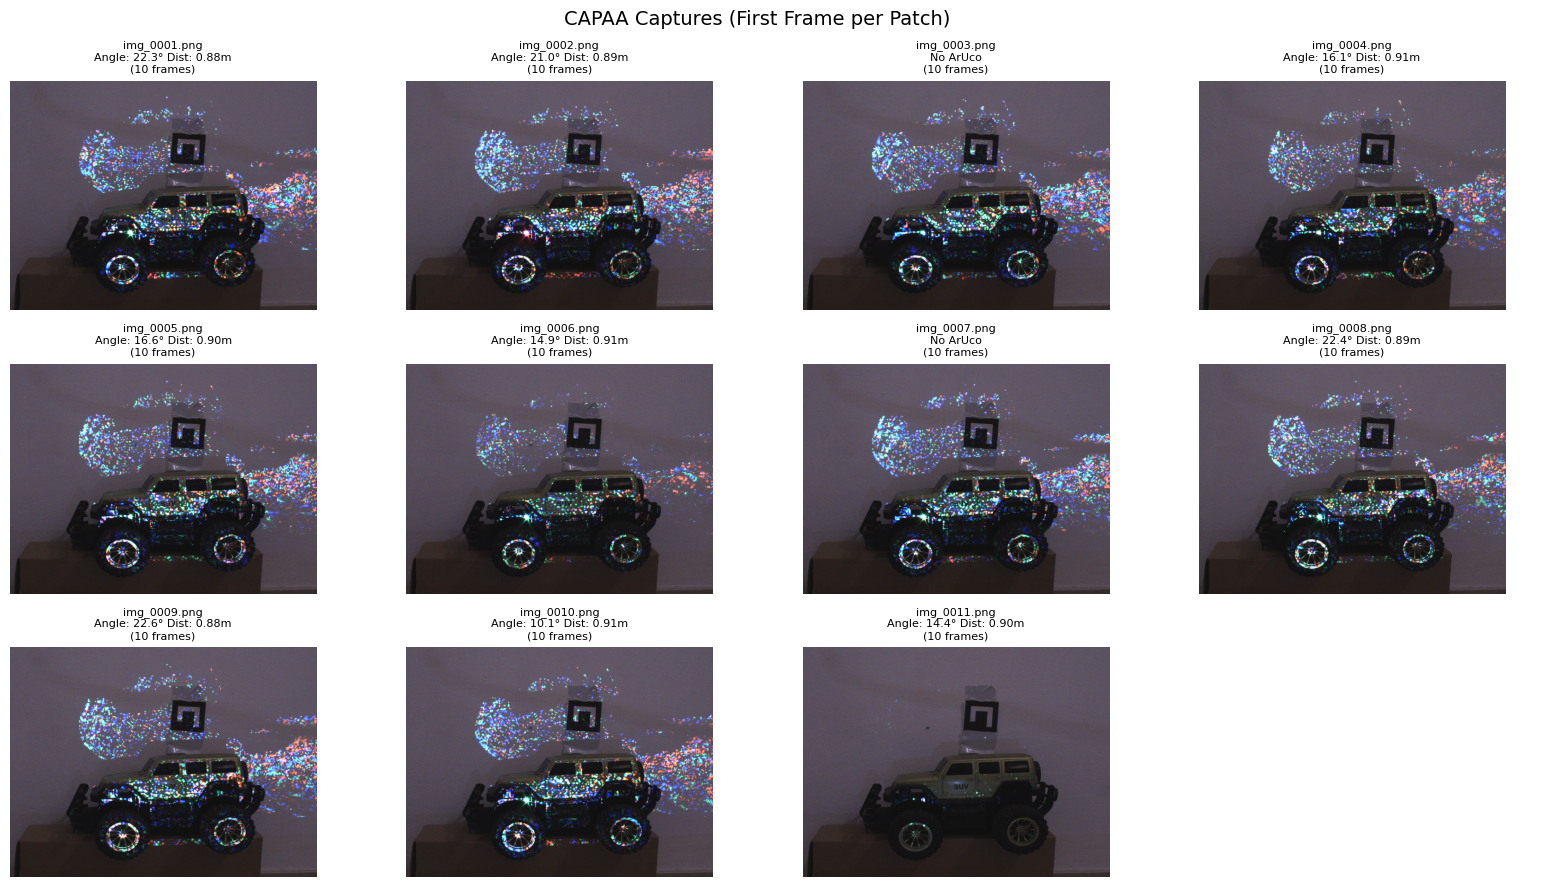

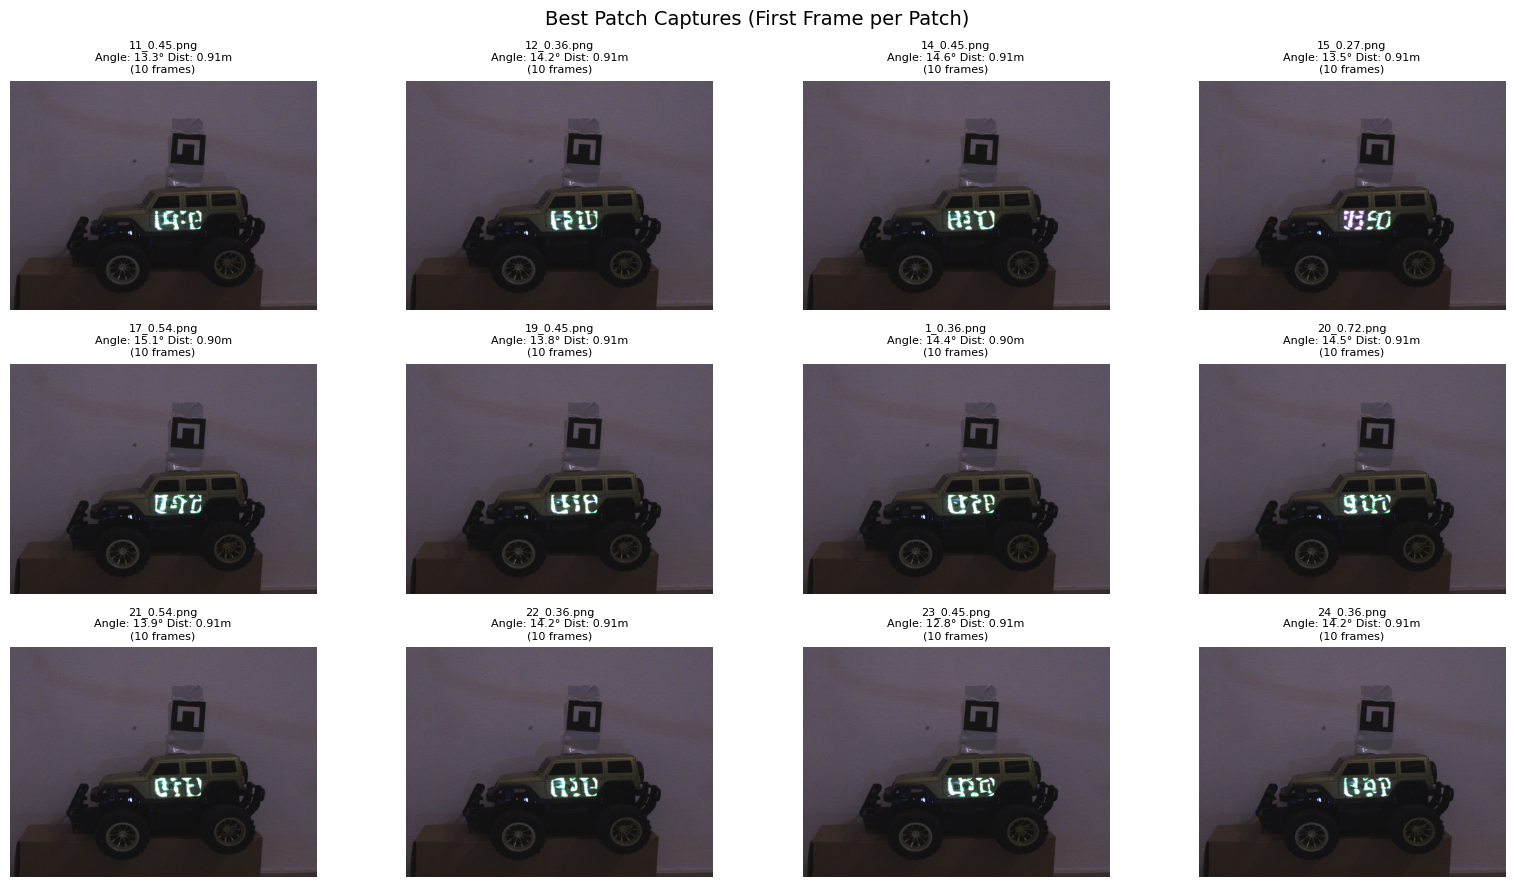

In [ ]:
# Visualize captured frames grid (show first frame of each capture)
# Supports multi-pose mode - shows pose index in title
def show_captures_grid(captures, title, max_cols=4, max_rows=3):
    """Show a grid of captured frames (first frame from each capture).
    In multi-pose mode, each capture is a (patch, pose) combination."""
    n = min(len(captures), max_cols * max_rows)
    if n == 0:
        print(f"No captures to display for {title}")
        return
    
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    
    is_multi_pose = 'pose_idx' in captures[0] if len(captures) > 0 else False
    
    for idx in range(n):
        row, col = idx // cols, idx % cols
        ax = axes[row][col]
        
        # Use first frame from the list of frames
        frame_rgb = cv2.cvtColor(captures[idx]['frames'][0], cv2.COLOR_BGR2RGB)
        ax.imshow(frame_rgb)
        
        patch_name = captures[idx]['patch_name'][:15] + '...' if len(captures[idx]['patch_name']) > 15 else captures[idx]['patch_name']
        angle = captures[idx]['angle']
        dist = captures[idx]['distance']
        num_frames = captures[idx]['num_frames']
        
        # Build title
        if is_multi_pose:
            pose_idx = captures[idx]['pose_idx']
            title_line1 = f"P{pose_idx+1}: {patch_name}"
        else:
            title_line1 = patch_name
        
        if angle is not None:
            title_line2 = f"Angle: {angle:.1f}° Dist: {dist:.2f}m"
        else:
            title_line2 = "No ArUco"
        
        title_line3 = f"({num_frames} frames)"
        
        ax.set_title(f"{title_line1}\n{title_line2}\n{title_line3}", fontsize=8)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(n, rows * cols):
        row, col = idx // cols, idx % cols
        axes[row][col].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

# Check if multi-pose
capaa_multi_pose = 'pose_idx' in capaa_captures[0] if len(capaa_captures) > 0 else False
bp_multi_pose = 'pose_idx' in best_patch_captures[0] if len(best_patch_captures) > 0 else False

# Show CAPAA captures
capaa_title = "CAPAA Captures (First Frame per Patch/Pose)" if capaa_multi_pose else "CAPAA Captures (First Frame per Patch)"
fig1 = show_captures_grid(capaa_captures, capaa_title)
if fig1:
    plt.savefig('capaa_captures_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Show Best Patch captures
bp_title = "Best Patch Captures (First Frame per Patch/Pose)" if bp_multi_pose else "Best Patch Captures (First Frame per Patch)"
fig2 = show_captures_grid(best_patch_captures, bp_title)
if fig2:
    plt.savefig('best_patch_captures_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save all results
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")
output_dir = f"batch_capture_results_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# Save dataframes
capaa_df.to_csv(f"{output_dir}/capaa_results.csv", index=False)
bp_df.to_csv(f"{output_dir}/best_patch_results.csv", index=False)

# Save summaries
capaa_summary.to_csv(f"{output_dir}/capaa_summary.csv", index=False)
bp_summary.to_csv(f"{output_dir}/best_patch_summary.csv", index=False)

# Save captures
with open(f"{output_dir}/capaa_captures.pkl", "wb") as f:
    pickle.dump(capaa_captures, f)
with open(f"{output_dir}/best_patch_captures.pkl", "wb") as f:
    pickle.dump(best_patch_captures, f)

print(f"✓ Results saved to '{output_dir}/'")
print(f"  - capaa_results.csv")
print(f"  - best_patch_results.csv")
print(f"  - capaa_summary.csv")
print(f"  - best_patch_summary.csv")
print(f"  - capaa_captures.pkl")
print(f"  - best_patch_captures.pkl")

✓ Results saved to 'batch_capture_results_2025-12-25_00_40/'
  - capaa_results.csv
  - best_patch_results.csv
  - capaa_summary.csv
  - best_patch_summary.csv
  - capaa_captures.pkl
  - best_patch_captures.pkl


In [ ]:
# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

capaa_total_frames = sum(c['num_frames'] for c in capaa_captures)
bp_total_frames = sum(c['num_frames'] for c in best_patch_captures)

# Check multi-pose
capaa_multi_pose = 'pose_idx' in capaa_captures[0] if len(capaa_captures) > 0 else False
bp_multi_pose = 'pose_idx' in best_patch_captures[0] if len(best_patch_captures) > 0 else False

if capaa_multi_pose:
    num_patches = len(set(c['patch_idx'] for c in capaa_captures))
    num_poses = len(set(c['pose_idx'] for c in capaa_captures))
    print(f"\nCAPAA: {num_patches} patches × {num_poses} poses = {len(capaa_captures)} captures, {capaa_total_frames} total frames")
else:
    print(f"\nCAPAA: {len(capaa_captures)} patches, {capaa_total_frames} total frames")

if bp_multi_pose:
    num_patches = len(set(c['patch_idx'] for c in best_patch_captures))
    num_poses = len(set(c['pose_idx'] for c in best_patch_captures))
    print(f"Best Patch: {num_patches} patches × {num_poses} poses = {len(best_patch_captures)} captures, {bp_total_frames} total frames")
else:
    print(f"Best Patch: {len(best_patch_captures)} patches, {bp_total_frames} total frames")

print(f"\n--- Frame-Level Average Success Rates ---")
print(f"  CAPAA: {capaa_summary['Frame Success Rate'].mean():.1f}%")
print(f"  Best Patch: {bp_summary['Frame Success Rate'].mean():.1f}%")

print(f"\n--- Patch-Level Average Success Rates (Majority Vote) ---")
print(f"  CAPAA: {capaa_summary['Patch Success Rate'].mean():.1f}%")
print(f"  Best Patch: {bp_summary['Patch Success Rate'].mean():.1f}%")

# Winner per model (using patch-level majority vote)
print(f"\nWinner per Model (Patch-Level):")
for i in range(len(capaa_summary)):
    model = capaa_summary.iloc[i]['Model']
    c_rate = capaa_summary.iloc[i]['Patch Success Rate']
    b_rate = bp_summary.iloc[i]['Patch Success Rate']
    
    if c_rate > b_rate:
        winner = 'CAPAA'
    elif b_rate > c_rate:
        winner = 'Best Patch'
    else:
        winner = 'Tie'
    
    print(f"  {model}: {winner} (CAPAA: {c_rate:.1f}% vs BP: {b_rate:.1f}%)")


FINAL SUMMARY

CAPAA: 11 patches × 110 total frames
Best Patch: 17 patches × 170 total frames

--- Frame-Level Average Success Rates ---
  CAPAA: 20.0%
  Best Patch: 54.8%

--- Patch-Level Average Success Rates (Majority Vote) ---
  CAPAA: 18.2%
  Best Patch: 53.9%

Winner per Model (Patch-Level):
  v1_inception: Best Patch (CAPAA: 9.1% vs BP: 100.0%)
  v1_resnet: Best Patch (CAPAA: 9.1% vs BP: 11.8%)
  v1_vgg: Tie (CAPAA: 0.0% vs BP: 0.0%)
  v1_vit: Best Patch (CAPAA: 0.0% vs BP: 100.0%)
  v1_dino: CAPAA (CAPAA: 54.5% vs BP: 0.0%)
  v1_combined: Best Patch (CAPAA: 9.1% vs BP: 100.0%)
  v2_convnext: Best Patch (CAPAA: 81.8% vs BP: 100.0%)
  v2_efficientnet: Tie (CAPAA: 0.0% vs BP: 0.0%)
  v2_mobilenet: Best Patch (CAPAA: 0.0% vs BP: 100.0%)
  v2_swin: Best Patch (CAPAA: 0.0% vs BP: 35.3%)
  v2_combined: Best Patch (CAPAA: 0.0% vs BP: 100.0%)
  dino_standalone: CAPAA (CAPAA: 54.5% vs BP: 0.0%)
